In [ ]:
#!pip3 install matplotlib opencv-python scikit-image tensorflow scikit-learn pandas
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Necesario para la gráfica 3D
#https://opencv.org
#!pip3 install opencv-python
import cv2
#https://scikit-image.org
#!pip3 install scikit-image
from skimage import data, color, filters, exposure, segmentation, feature
from skimage.filters import threshold_otsu, prewitt
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

/Users/carlosvasquezguerra/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# Imagenes

In [43]:
# --------------------------
# Helpers: mostrar imágenes
# --------------------------
def show_images(imgs, titles=None, cmap_list=[], figsize=(12,4)):
    n = len(imgs)
    plt.figure(figsize=figsize)
    for i, img in enumerate(imgs):
        plt.subplot(1, n, i+1)
        if img is None:
            plt.axis('off'); continue
        # Distinguir entre imagen en escala de grises y color
        if img.ndim == 2:
            #Si img.ndim == 2 se considera escala de grises a menos que se indique lo contrario
            plt.imshow(img, cmap=cmap_list[i] if len(cmap_list)>0 else 'gray')
        else:
            # convert BGR->RGB if using OpenCV images
            if img.shape[2] == 3:
                try:
                    # Matplotlib espera imágenes en RGB; OpenCV por defecto tiene imágenes en BGR
                    #Para evitar colores invertidos, la función intenta convertir BGR→RGB mediante cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                except Exception:
                    plt.imshow(img)
            else:
                plt.imshow(img)
        if titles and i < len(titles):
            plt.title(titles[i])
        plt.axis('off')
    plt.show()

skimage trae algunas imágenes de ejemplo útiles

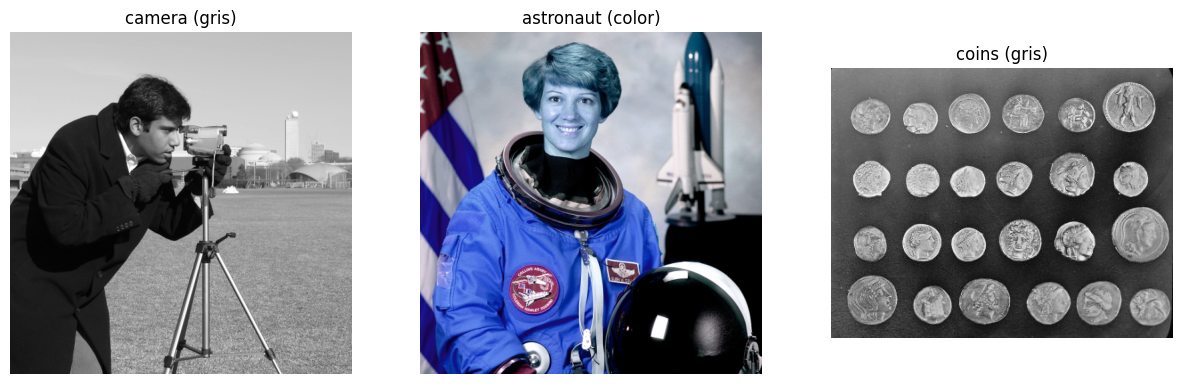

In [44]:
img_camera = data.camera()               # escala de grises
img_astronaut = data.astronaut()         # color
img_coins = data.coins()                 # buena para segmentación

show_images([img_camera, img_astronaut, img_coins],
            titles=['camera (gris)', 'astronaut (color)', 'coins (gris)'],
            figsize=(15,5))

# Codificación en imágenes digitales

Una imagen no es más que una matriz (o tensor) de números que representan la intensidad del color en cada píxel.

La forma en que se codifica el color se llama espacio de color.

1. Escala de grises (1 canal)
+ Cada píxel se describe con 1 valor de intensidad (0–255 en 8 bits).
+ 0 = negro, 255 = blanco.
+ Ejemplo: radiografías, documentos escaneados.
+ Forma en memoria: (alto, ancho) o (alto, ancho, 1).

2. RGB (3 canales)
+ El estándar más común en pantallas.
+ Cada píxel tiene 3 valores: Rojo (R), Verde (G), Azul (B).
+ Al combinarse en distintas intensidades → forman millones de colores.
+ Rango típico: 0–255 (8 bits por canal).
+ Forma en memoria: (alto, ancho, 3).
+ Ejemplo: una imagen de 200x300 píxeles en RGB ocupa un tensor (200,300,3).

3. RGBA (4 canales)
+ Igual que RGB pero con un canal extra: A (alpha) = transparencia.
+ 0 = completamente transparente, 255 = opaco.
+ Muy usado en gráficos y superposición de imágenes.
+ Forma: (alto, ancho, 4).

4. Espacios alternativos
+ HSV / HSL
    - H (Hue) = tono (ej. rojo, azul, verde).
    - S (Saturation) = intensidad del color.
    - V/L (Value/Lightness) = brillo.
    - Útil para segmentación porque separa “qué color es” de “qué tan brillante o saturado está”.
+ YUV / YCbCr
    - Usados en video y compresión (JPEG, MPEG).
    - Separan luminancia (Y = brillo) de crominancia (Cb, Cr = información de color).
    - Aprovechan que el ojo humano es más sensible a los cambios de brillo que al color.
+ CMYK
    - Cian, Magenta, Amarillo, Negro.
    - Estándar en impresión.
    - Diferente de RGB porque está pensado en pigmentos, no en luz.
+ Lab (CIE L*a*b*)
    - L* = luminosidad: Representa el componente de claridad u oscuridad del color, variando de 0 (negro) a 100 (blanco). 
    - a* = Eje rojo/verde: Indica la cromaticidad, donde los valores positivos de a\* se inclinan hacia el rojo y los valores negativos hacia el verde. 
    - b* = Eje amarillo/azul: Indica la cromaticidad en la otra dirección, con valores positivos apuntando hacia el amarillo y los negativos hacia el azul. 
    - Muy útil para procesamiento avanzado y detección de objetos porque separa luminosidad de color de forma perceptualmente uniforme.
    - Ejemplo: para segmentar objetos de un mismo color aunque tengan sombras.

5. Bit depth (profundidad de color)
+ Define cuántos valores posibles puede tomar cada canal.
+ 8 bits por canal (0–255) = estándar en imágenes comunes.
+ 16 bits o más = imágenes HDR, médicas o científicas (mucha más precisión).

RGB: (100, 100, 3)
Grayscale: (100, 100)
RGBA: (100, 100, 4)


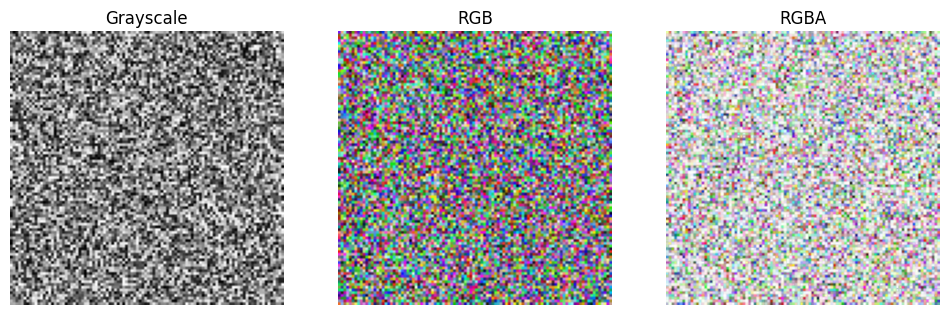

In [34]:
# Imagen RGB aleatoria
img_rgb = np.random.randint(0, 256, (100, 100, 3), dtype=np.uint8)
print("RGB:", img_rgb.shape)

# Escala de grises
img_gray = np.random.randint(0, 256, (100, 100), dtype=np.uint8)
print("Grayscale:", img_gray.shape)

# RGBA
img_rgba = np.random.randint(0, 256, (100, 100, 4), dtype=np.uint8)
print("RGBA:", img_rgba.shape)

# Visualización
fig, axs = plt.subplots(1, 3, figsize=(12,4))
axs[0].imshow(img_gray, cmap="gray"); axs[0].set_title("Grayscale")
axs[1].imshow(img_rgb); axs[1].set_title("RGB")
axs[2].imshow(img_rgba); axs[2].set_title("RGBA")
for ax in axs: ax.axis("off")
plt.show()


## Dimensiones en gráficas

+ 1D (una dimensión): Solo un eje (por ejemplo, el tiempo). Se suele representar como una línea sobre el tiempo o un histograma.
+ 2D (dos dimensiones): Dos ejes: x y y. Ejemplo: diagrama de dispersión donde cada punto tiene una coordenada (x,y).
+ 3D (tres dimensiones): Tres ejes: x, y, z. Ejemplo: nube de puntos en el espacio o una superficie.
+ Más de 3D: No podemos “ver” dimensiones mayores directamente, pero podemos codificar dimensiones extra en otros aspectos visuales:
    - Color
    - Tamaño del marcador
    - Forma del marcador
    - Transparencia
    - Animación (usando tiempo como una “cuarta dimensión”)

Esto permite representar datos de 4, 5 o más variables en una gráfica, aunque no sea un espacio físico 4D.

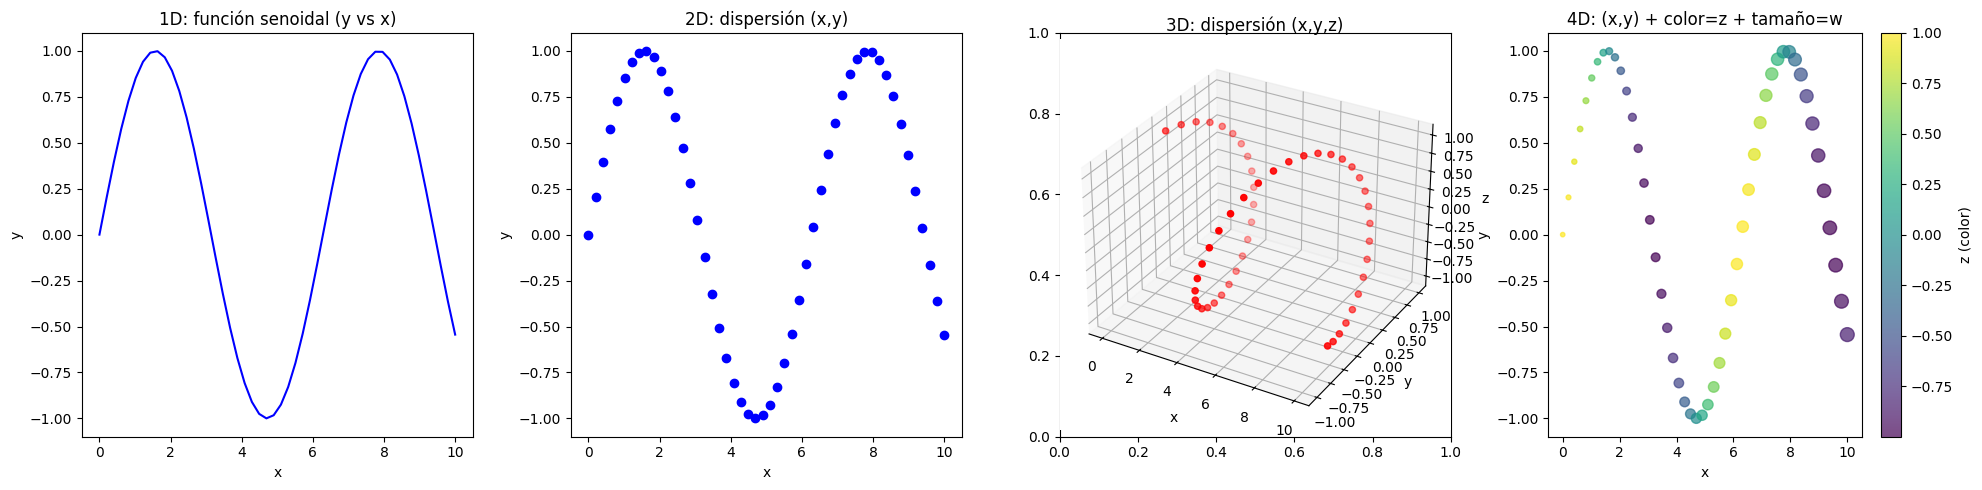

In [30]:
# Ejemplo de datos
x = np.linspace(0, 10, 50)
y = np.sin(x)
z = np.cos(x)
w = np.linspace(1, 10, 50)  # variable extra (tamaño/color)

# Ejemplo de datos
x = np.linspace(0, 10, 50)
y = np.sin(x)
z = np.cos(x)
w = np.linspace(1, 10, 50)  # variable extra (tamaño/color)

# Crear figura con 1 fila y 4 columnas
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# --- 1D ---
axes[0].plot(x, y, color="blue")
axes[0].set_title("1D: función senoidal (y vs x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# --- 2D ---
axes[1].scatter(x, y, c='blue')
axes[1].set_title("2D: dispersión (x,y)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# --- 3D ---
ax3d = fig.add_subplot(1, 4, 3, projection='3d')  # tercer subplot en 3D
ax3d.scatter(x, y, z, c='red')
ax3d.set_title("3D: dispersión (x,y,z)")
ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel("z")

# --- 4D ---
sc = axes[3].scatter(x, y, c=z, s=w*10, cmap='viridis', alpha=0.7)
axes[3].set_title("4D: (x,y) + color=z + tamaño=w")
axes[3].set_xlabel("x")
axes[3].set_ylabel("y")
fig.colorbar(sc, ax=axes[3], label="z (color)")

# Ajustar espaciado
plt.tight_layout()
plt.show()

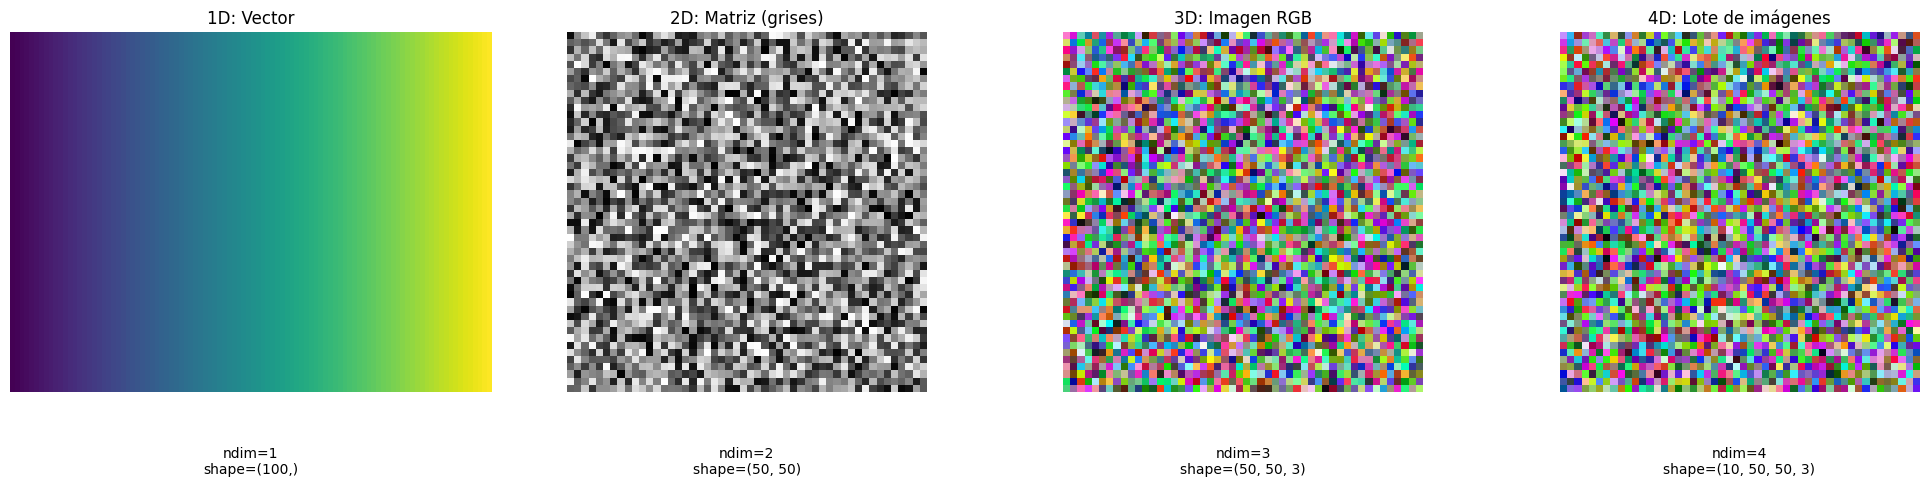

In [33]:
# Crear datos
vec = np.linspace(0, 1, 100)              # 1D
mat = np.random.rand(50, 50)              # 2D
img = np.random.rand(50, 50, 3)           # 3D
batch = np.random.rand(10, 50, 50, 3)     # 4D

# Crear figura 1x4
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# --- 1D ---
axes[0].imshow(vec[np.newaxis, :], cmap="viridis", aspect="auto")
axes[0].set_title("1D: Vector")
axes[0].axis("off")
axes[0].text(0.5, -0.15, f"ndim={vec.ndim}\nshape={vec.shape}",
             transform=axes[0].transAxes, ha="center", va="top")

# --- 2D ---
axes[1].imshow(mat, cmap="gray")
axes[1].set_title("2D: Matriz (grises)")
axes[1].axis("off")
axes[1].text(0.5, -0.15, f"ndim={mat.ndim}\nshape={mat.shape}",
             transform=axes[1].transAxes, ha="center", va="top")

# --- 3D ---
axes[2].imshow(img)
axes[2].set_title("3D: Imagen RGB")
axes[2].axis("off")
axes[2].text(0.5, -0.15, f"ndim={img.ndim}\nshape={img.shape}",
             transform=axes[2].transAxes, ha="center", va="top")

# --- 4D (Conunto de imágenes: visualizamos la primera imagen del lote) ---
axes[3].imshow(batch[0])
axes[3].set_title("4D: Lote de imágenes")
axes[3].axis("off")
axes[3].text(0.5, -0.15, f"ndim={batch.ndim}\nshape={batch.shape}",
             transform=axes[3].transAxes, ha="center", va="top")

plt.tight_layout()
plt.show()


## Escalas de colores

https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.Colormap.html#matplotlib.colors.Colormap

En plt.imshow(img, cmap="...") o plt.scatter(..., cmap="...") se define cómo transformar los valores numéricos en colores. 

+ Mapas de colores secuenciales (para datos con un orden claro, como temperatura o intensidad):
    - 'viridis': Este es el mapa de colores predeterminado en Matplotlib y es perceptualmente uniforme, lo que significa que los cambios en los valores de los datos se perciben como cambios de color iguales. Va del azul oscuro/morado al amarillo brillante.
    - 'plasma': Otro mapa de colores perceptualmente uniforme, similar a viridis, pero con una progresión de color ligeramente diferente.
    - 'magma': Un mapa de colores secuencial que va del oscuro al brillante, con un tono rojizo-morado.
    - 'cividis': Diseñado para ser perceptualmente uniforme y también accesible para personas daltónicas.
    - 'gray' or 'Greys': Para mostrar imágenes en escala de grises, donde los valores más bajos son más oscuros y los más altos, más claros.
    - 'Blues', 'Greens', 'Reds': Mapas de colores secuenciales monocromáticos, útiles para resaltar rangos o canales específicos.
+ Escalas divergentes (para datos con un valor medio crítico, como desviaciones de cero):
    - 'coolwarm': Va desde colores fríos (azul), pasando por un punto medio neutro (blanco), hasta llegar a colores cálidos (rojo).
    - 'bwr': Representa azul-blanco-rojo, un mapa de colores divergente clásico.
    - 'RdBu': Rojo-azul, otro mapa de colores divergente común.
+ Mapas de colores cualitativos (para datos categóricos sin un orden específico):
    - 'tab10', 'tab20': Diseñados para proporcionar colores distintos para un número determinado de categorías.
+ Escalas cíclicas: Para datos que vuelven a empezar (ejemplo: ángulos, fases, direcciones del viento).
    - 'hsv' (tono circular)
    - 'twilight', 'twilight_shifted'
+ Escalas personalizadas
```
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("mi_cmap", ["blue","white","red"])
plt.imshow(data, cmap=cmap)
```

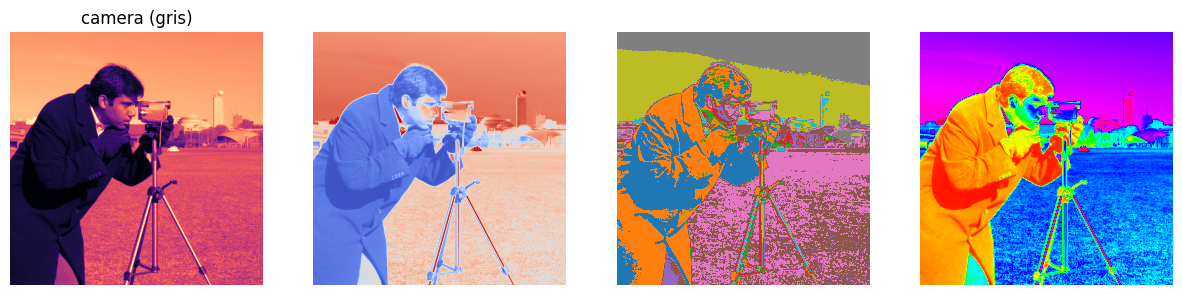

In [48]:
show_images([img_camera, img_camera, img_camera, img_camera],
            titles=['camera (gris)'],
            cmap_list=['magma', 'coolwarm', 'tab10', 'hsv'], figsize=(15,5))

# Principios básicos: agrupar por color, intensidad, textura

- Color: usar espacio RGB, HSV o Lab para separar tonos
- Intensidad: imágenes en escala de grises o la componente L en Lab
- Textura: features como LBP, filtros de Gabor o histogramas locales

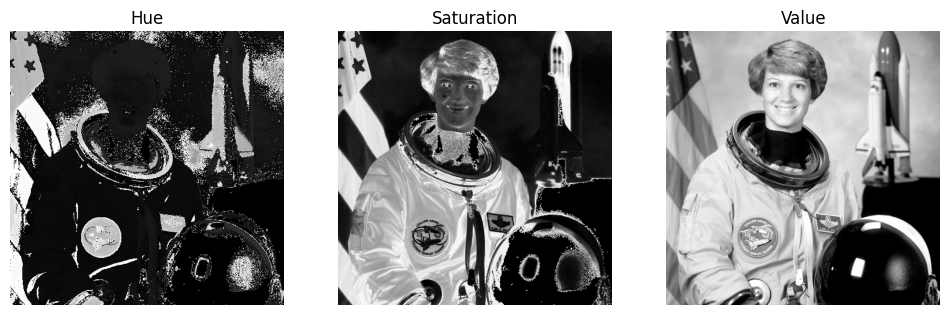

In [58]:
# Ejemplo: convertir a HSV y mostrar canales (útil para separar por tono)
# https://docs.opencv.org/3.4/d8/d01/group__imgproc__color__conversions.html
img_hsv = cv2.cvtColor(img_astronaut, cv2.COLOR_RGB2HSV)
   # - H (Hue) = tono (ej. rojo, azul, verde).
   # - S (Saturation) = intensidad del color.
   # - V/L (Value/Lightness) = brillo.
h, s, v = cv2.split(img_hsv)
show_images([h, s, v], titles=['Hue', 'Saturation', 'Value'], cmap_list=['gray']*3, figsize=(12,4))

In [62]:
img = cv2.imread("pexels-engin-lifestyle-357822307-14377436.jpg")
img

array([[[207, 207, 207],
        [206, 206, 206],
        [206, 206, 206],
        ...,
        [206, 206, 206],
        [206, 206, 206],
        [206, 206, 206]],

       [[208, 208, 208],
        [207, 207, 207],
        [207, 207, 207],
        ...,
        [206, 206, 206],
        [206, 206, 206],
        [206, 206, 206]],

       [[209, 209, 209],
        [208, 208, 208],
        [208, 208, 208],
        ...,
        [206, 206, 206],
        [206, 206, 206],
        [206, 206, 206]],

       ...,

       [[  0,  13,  29],
        [  1,  17,  33],
        [  3,  18,  34],
        ...,
        [134, 144, 151],
        [135, 145, 152],
        [136, 146, 153]],

       [[  0,  13,  28],
        [  0,  17,  32],
        [  1,  17,  33],
        ...,
        [121, 130, 139],
        [122, 131, 140],
        [123, 132, 141]],

       [[  0,  12,  27],
        [  0,  17,  32],
        [  1,  17,  33],
        ...,
        [109, 118, 127],
        [111, 120, 129],
        [112, 121, 130]]

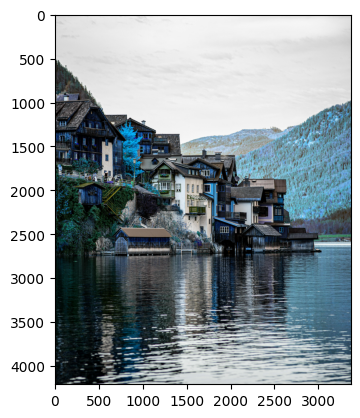

In [ ]:
plt.imshow(img)
plt.axis("off")

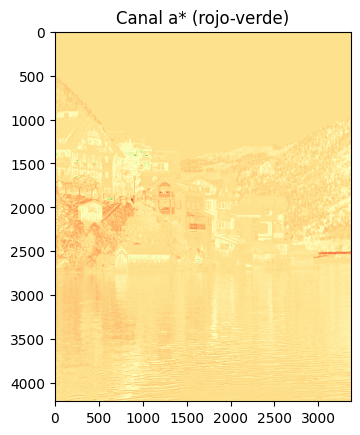

In [ ]:
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
plt.imshow(img_lab[:,:,1], cmap="RdYlGn")  # canal a* (rojo-verde)
plt.title("Canal a* (rojo-verde)")
plt.show()
plt.axis("off")

### Textura en imágenes

La textura describe cómo varían las intensidades localmente, capturando patrones repetitivos, rugosidades o estructuras. Es clave para clasificación y segmentación.

1. LBP (Local Binary Patterns)
- Convierte la vecindad de cada píxel en un código binario comparando con el valor central.
- Resultado: histograma de patrones locales → describe textura.
- Muy usado en reconocimiento facial y detección de superficies.

2. Filtros de Gabor
- Detectan frecuencia y orientación local → útiles para texturas lineales o patrones repetitivos.
- Ejemplo: detectar rayas, bordes periódicos, tejidos.

3. Histogramas locales (Local Histograms)
- Divide la imagen en regiones y calcula histogramas de intensidades o colores.
- Captura variaciones locales → útil en detección de objetos y segmentación basada en textura.

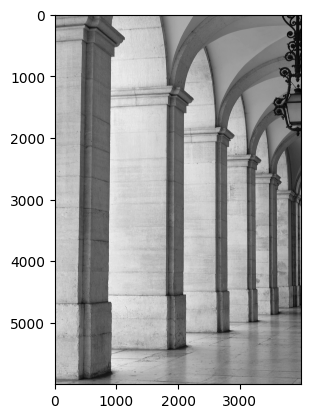

In [ ]:
from skimage.feature import local_binary_pattern
from skimage import io, color
img_gray = color.rgb2gray(io.imread("pexels-ulkar-batista-3827543-33011055.jpg"))
plt.imshow(img_gray, cmap="gray")
plt.axis("off")

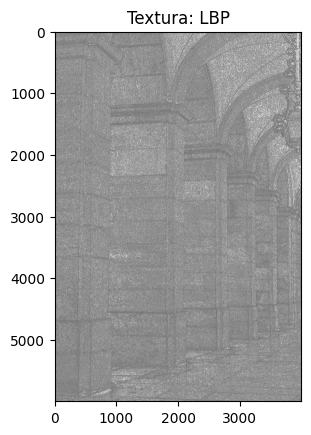

In [ ]:
lbp = local_binary_pattern(img_gray, P=8, R=1, method="uniform")
plt.imshow(lbp, cmap="gray")
plt.title("Textura: LBP")
plt.show()
plt.axis("off")

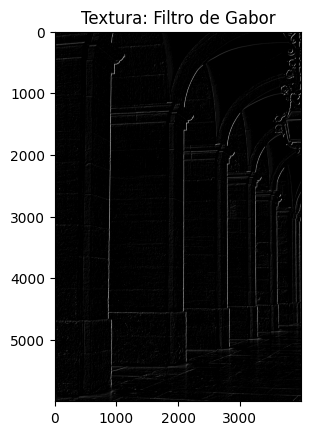

In [ ]:
#Kernel más pequeño → menos detalle extremo.
#Sigma más grande → suaviza la respuesta del filtro.
#Lambda mayor → ondas más largas, menos abruptas.
#Gamma más cercano a 1 → menos alargamiento de la función
kernel = cv2.getGaborKernel((15,15), sigma=8, theta=np.pi/4, lambd=20, gamma=0.8)
filtered = cv2.filter2D(img_gray, cv2.CV_8UC3, kernel)
plt.imshow(filtered, cmap="gray")
plt.title("Textura: Filtro de Gabor")
plt.show()
plt.axis("off")

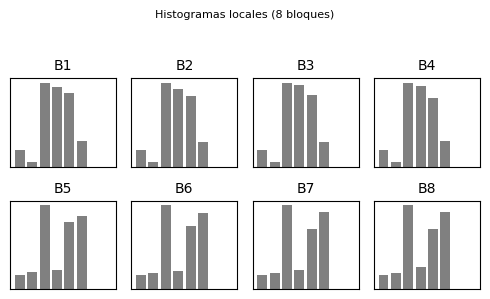

In [98]:
blocks = np.array_split(img_gray, 4, axis=0)

fig, axs = plt.subplots(2, 4, figsize=(5,3))
for i in range(2):
    for j in range(4):
        block = blocks[i][j]
        # Calcular histograma del bloque
        hist, bins = np.histogram(block, bins=8, range=(0,1))
        axs[i, j].bar(range(8), hist, color='gray')
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].set_title(f"B{i*4+j+1}", fontsize=10)

plt.suptitle("Histogramas locales (8 bloques)", fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Segmentación

## Segmentación por umbral (thresholding)
Idea: separar píxeles por intensidad

Comentario: La segmentación por umbral es simple pero funciona mejor cuando hay contraste claro entre objeto y fondo. Fallará con iluminación no uniforme.

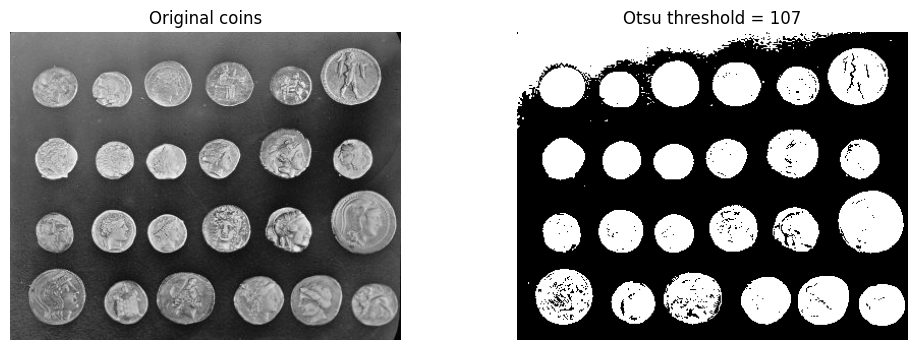

In [ ]:
gray_coins = img_coins
#Otsu automatico busca un umbral que minimice la varianza intra-clase
th = threshold_otsu(gray_coins)
mask_otsu = gray_coins > th
show_images([gray_coins, mask_otsu], titles=['Original coins', f'Otsu threshold = {th}'], cmap_list=['gray']*2)

## Crecimiento de regiones (region growing)

Es una técnica de segmentación basada en píxeles que agrupa píxeles en regiones similares según algún criterio, normalmente intensidad, color o textura.

Idea básica: 

+ Se elige un píxel semilla (seed pixel), que inicia la región.
+ Se comparan los píxeles vecinos con la semilla:
+ Si son similares (según un umbral), se agregan a la región.
+ Si no, se descartan.
+ El proceso continúa recursivamente con los nuevos píxeles añadidos a la región.
+ Se repite hasta que ningún píxel vecino cumple el criterio.

Útil para aislar regiones continuas con características similares

Comentario: region growing es sensible a la semilla y al umbral. Puede crecer indebidamente si hay ruido o si el umbral es muy grande.

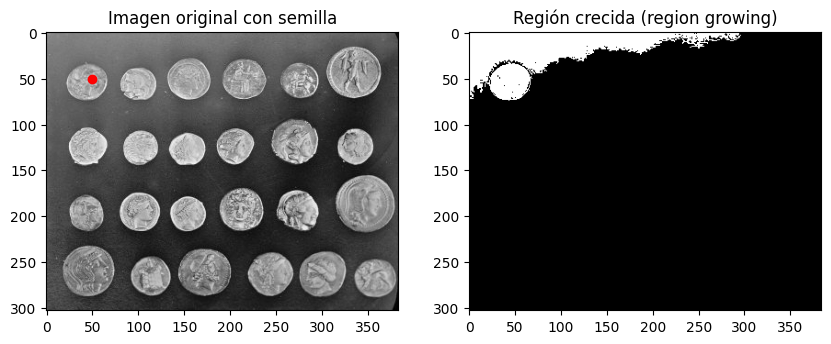

In [ ]:
from skimage.segmentation import flood, flood_fill

# Imagen en gris
seed_point = (50, 50)               # píxel semilla

# Región creciendo con un umbral
mask = flood(img_coins, seed_point, tolerance=50)  # tolerancia = similitud. Cambiar semilla

# Visualización
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_coins, cmap="gray")
plt.plot(seed_point[1], seed_point[0], "ro")  # semilla
plt.title("Imagen original con semilla")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Región crecida (region growing)")
plt.show()

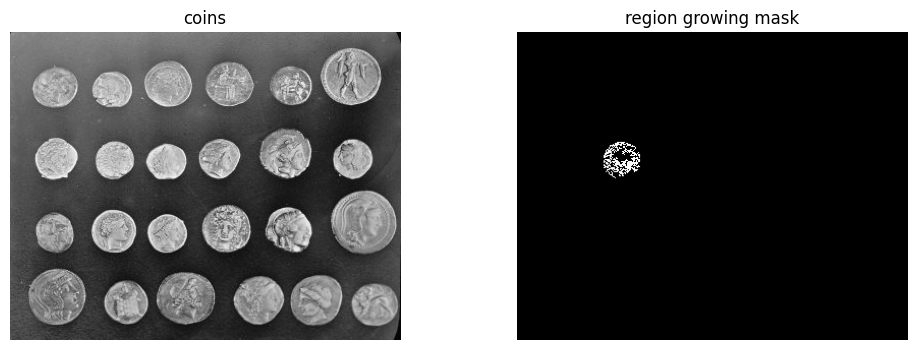

In [110]:
from collections import deque

def region_growing(img, seed, th=10):
    # img: imagen en escala de grises (0-255)
    # seed: (r,c)
    # th: umbral de diferencia absoluta con la media de la región
    h, w = img.shape
    visited = np.zeros((h,w), dtype=bool)
    mask = np.zeros((h,w), dtype=bool)
    q = deque([seed])
    visited[seed] = True
    region_vals = [int(img[seed])]
    while q:
        r,c = q.popleft()
        mask[r,c] = True
        # vecinos 8-conectividad
        for dr in [-1,0,1]:
            for dc in [-1,0,1]:
                nr, nc = r+dr, c+dc
                if nr<0 or nr>=h or nc<0 or nc>=w: continue
                if visited[nr,nc]: continue
                visited[nr,nc] = True
                val = int(img[nr,nc])
                mean_reg = np.mean(region_vals)
                if abs(val - mean_reg) <= th:
                    region_vals.append(val)
                    q.append((nr,nc))
    return mask

# Aplicar region growing en coins (semilla manual)
seed = (120, 120)  # probar con diferentes semillas
mask_rg = region_growing(gray_coins, seed, th=12)
show_images([gray_coins, mask_rg], titles=['coins', 'region growing mask'], cmap_list=['gray']*2)

## Segmentación por clustering: k-means

Se agrupan píxeles en k clusters usando color y/o posición

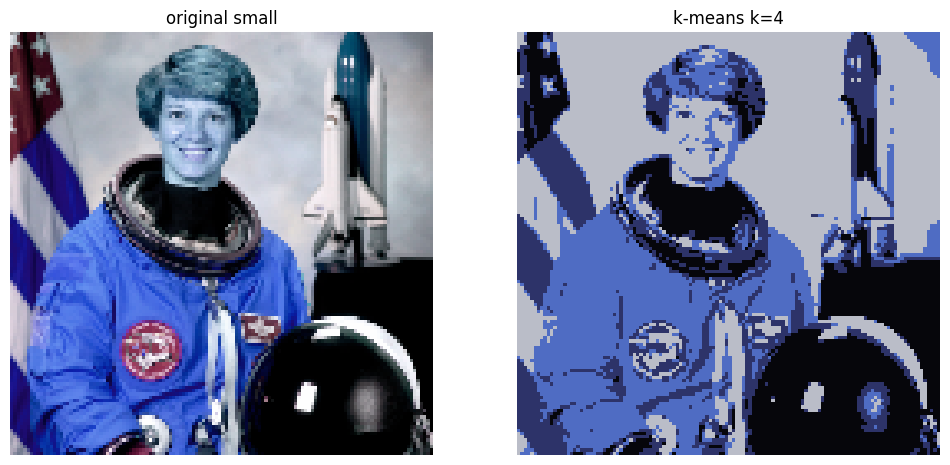

In [121]:
img = img_astronaut.copy()
img_small = cv2.resize(img, (128,128))
Z = img_small.reshape((-1,3))
Z = np.float32(Z)

k = 4
kmeans = KMeans(n_clusters=k, random_state=0).fit(Z)
labels = kmeans.labels_.reshape(img_small.shape[:2])

# reconstruir imagen por cluster centroides
centers = np.uint8(kmeans.cluster_centers_)
segmented = centers[labels]
show_images([img_small, segmented], titles=['original small', f'k-means k={k}'], cmap_list=None, figsize=(12,6))

# Comentario: K-means agrupa por color/intensidad. Incorporar coordenadas espaciales
# (x,y) ayuda a que los clusters sean más compactos espacialmente.

# Detección de bordes

La detección de bordes se basa en encontrar discontinuidades bruscas de intensidad o color en una imagen. Un borde indica límites de objetos, cambios de textura o contornos.

+ Métodos comunes: Los operadores de gradiente estiman la tasa de cambio de intensidad en cada píxel. (Sobel, Prewitt) y Canny (detector multi-etapa).
    - Sobel
        - Ventaja: suaviza algo de ruido debido al kernel ponderado.
        - Desventaja: puede detectar bordes gruesos si la imagen tiene mucho ruido.
    - Prewitt
        - Ventaja: simple y rápido.
        - Desventaja: menos robusto al ruido que Sobel.
    - Canny
        - Más sofisticado, considerado uno de los mejores detectores de bordes.

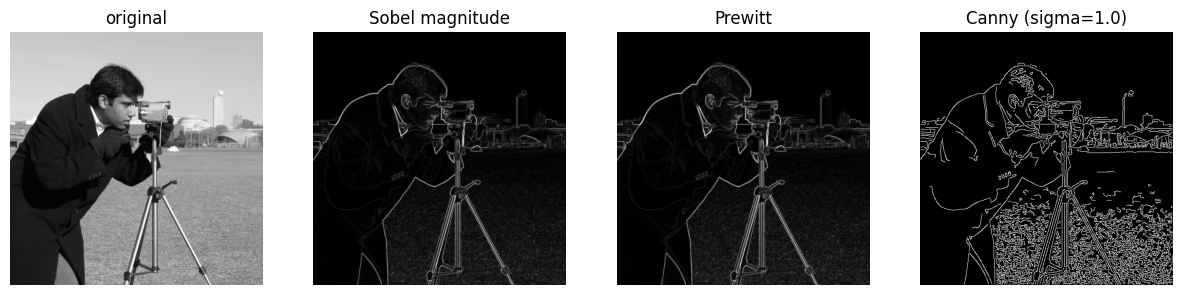

In [123]:
# Sobel
sobelx = filters.sobel_h(img_camera)   # gradiente horizontal (skimage devuelve 0..1)
sobely = filters.sobel_v(img_camera)   # gradiente vertical
magnitude = np.hypot(sobelx, sobely)

# Prewitt
prew = prewitt(img_camera)

# Canny (skimage)
canny = feature.canny(img_camera, sigma=1.0)

show_images([img_camera, magnitude, prew, canny],
            titles=['original', 'Sobel magnitude', 'Prewitt', 'Canny (sigma=1.0)'], cmap_list=['gray']*4, figsize=(15,6))

Variabilidad de Condiciones en la detección de bordes: La efectividad de estas técnicas puede verse afectada por factores como la iluminación, la sombra y la ocultación parcial de objetos. 

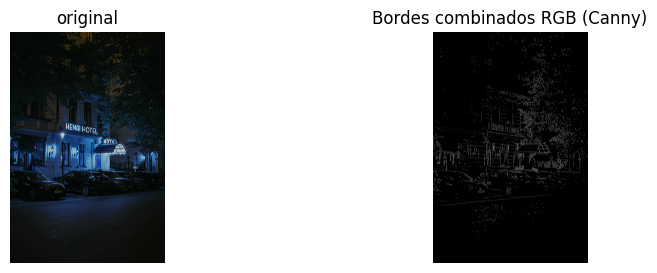

In [133]:
img = io.imread("pexels-studio-buttons-2155820368-33915746.jpg")

edges = np.zeros(img.shape[:2])  # imagen final 2D

# Aplicar Canny por canal
for c in range(3):
    edges += feature.canny(img[:,:,c], sigma=1)**2

edges = np.sqrt(edges)

show_images([img, edges],
            titles=['original', "Bordes combinados RGB (Canny)"], cmap_list=['gray']*2, figsize=(10,3))

La elección adecuada de parámetros es crucial para el éxito de estas técnicas, requiriendo un equilibrio entre la sensibilidad a los detalles y la robustez ante el ruido. 

Por ejemplo, sigma y umbrales en Canny controlan sensibilidad y robustez al ruido. Ajustar requiere balance entre detectar detalles finos y evitar falsos positivos por ruido.
+ mayor sigma -> mayor suavizado -> menos bordes finos

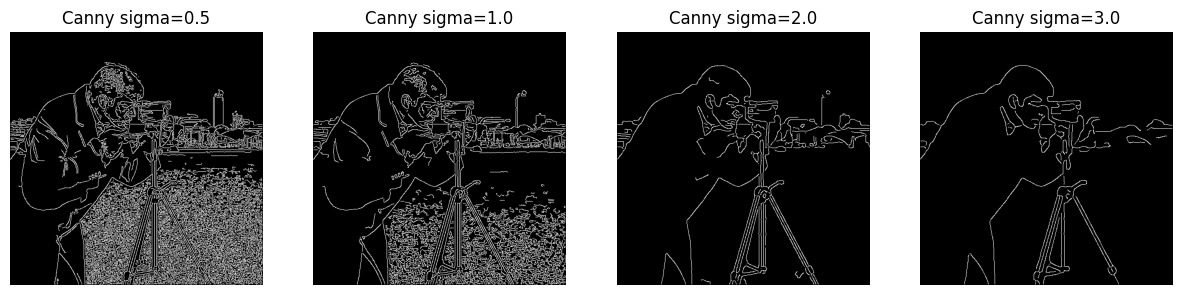

In [125]:
# Ejemplo de efecto de parámetros en Canny
edges = []
for sigma in [0.5, 1.0, 2.0, 3.0]:
    edges.append(feature.canny(img_camera, sigma=sigma))

show_images(edges,
            titles=['Canny sigma=0.5', 'Canny sigma=1.0', 'Canny sigma=2.0', 'Canny sigma=3.0'], cmap_list=['gray']*4, figsize=(15,6))

# Detección de objetos

En muchos pipelines se detectan regiones con contornos y se filtran por área, forma, etc.

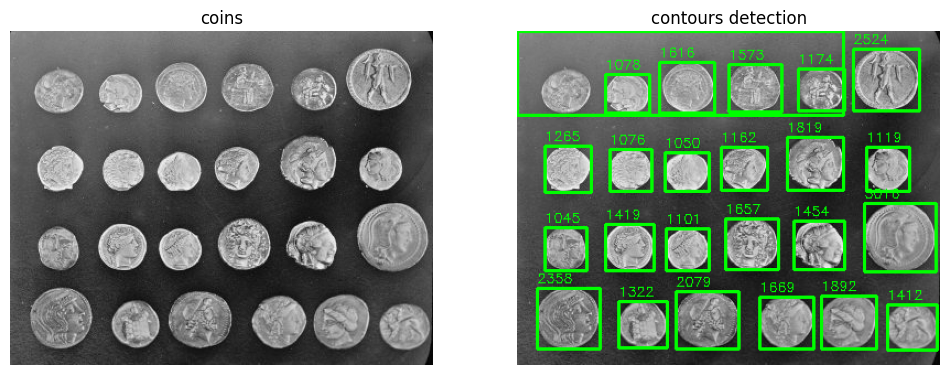

In [ ]:
#Se convierte la imagen a algo que sea más fácil de segmentar objetos.
#Se genera una imagen binaria (blanco y negro): 0 → negro (fondo) 255 → blanco (objetos)
#cv2.THRESH_OTSU selecciona automáticamente un umbral óptimo usando la histograma de la imagen.
#ret: valor de umbral encontrado por Otsu.
#th_cv: imagen binaria resultante.
ret, th_cv = cv2.threshold(gray_coins, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#cv2.findContours detecta bordes cerrados (contornos) en la imagen binaria.
##Parámetros importantes:
##th_cv.astype(np.uint8) → la imagen debe ser entero 8 bits.
##cv2.RETR_EXTERNAL → solo recupera contornos externos (ignora huecos internos).
##cv2.CHAIN_APPROX_SIMPLE → simplifica contornos, eliminando puntos redundantes.
##contours → lista de contornos (cada uno es un array de puntos (x,y)).
##hierarchy → información jerárquica (padre/hijo), útil si hay contornos dentro de otros contornos.
contours, hierarchy = cv2.findContours(th_cv.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#Se convierte la imagen grises → color (BGR) para poder dibujar rectángulos y texto de colores sobre ella.
img_cont = cv2.cvtColor(gray_coins, cv2.COLOR_GRAY2BGR)
#Se itera sobre contornos y se filtra por área
for i, c in enumerate(contours):
    #cv2.contourArea(c) → calcula el área del contorno en píxeles.
    area = cv2.contourArea(c)
    #Si el área es menor a 100 píxeles → se descarta (ruido o pequeños objetos).
    if area < 100: continue
    #Se dibuja un rectángulo y poner el área
    x,y,w,h = cv2.boundingRect(c)
    cv2.rectangle(img_cont, (x,y), (x+w, y+h), (0,255,0), 2)
    #Se escribe el área del contorno encima del rectángulo.
    cv2.putText(img_cont, f'{int(area)}', (x,y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0), 1)

show_images([gray_coins, img_cont], titles=['coins', 'contours detection'], cmap_list=['gray']*2, figsize=(12,6))

Esta es una alternativa clásica basada en segmentación + contornos pero para detección de objetos robusta se usan modelos entrenados (YOLO, SSD, Faster-RCNN).

# Detección de rostros: Haar cascades

Extraemos características faciales y luego se identifica. OpenCV trae clasificadores Haar que funcionan rápido aunque no perfectos

La detección de rostros extrae características únicas (distancias entre ojos, forma de la nariz, etc.) y permite reconocimiento cuando se usan descriptores (Fisherfaces, LBPH, embeddings de redes profundas).

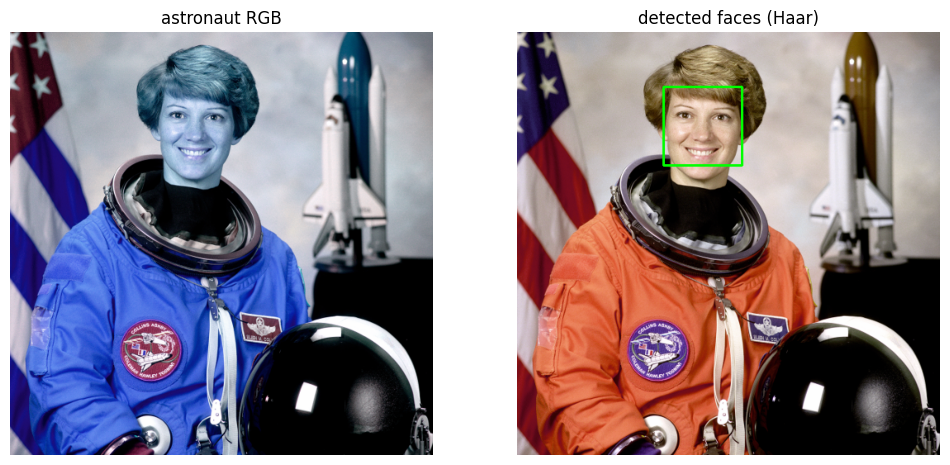

In [135]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Convertir astronaut a BGR para OpenCV detect
img_astr_bgr = cv2.cvtColor(img_astronaut, cv2.COLOR_RGB2BGR)
gray = cv2.cvtColor(img_astr_bgr, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
img_faces = img_astr_bgr.copy()
for (x,y,w,h) in faces:
    cv2.rectangle(img_faces, (x,y), (x+w, y+h), (0,255,0), 2)

show_images([img_astronaut, img_faces], titles=['astronaut RGB', 'detected faces (Haar)'], cmap_list=[None]*2, figsize=(12,6))

# CNN

Arquitectura típica: Convolution -> Activation -> Pooling -> (repetir) -> Flatten -> Dense

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 119s 1us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.1667 - loss: 2.1894 - val_accuracy: 0.2615 - val_loss: 1.9097
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.2731 - loss: 1.8874 - val_accuracy: 0.2855 - val_loss: 1.8345
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3181 - loss: 1.7712 - val_accuracy: 0.3835 - val_loss: 1.6821
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3728 - loss: 1.6589 - val_accuracy: 0.3865 - val_loss: 1.6845
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4004 - loss: 1.5831 - val_accuracy: 0.4010 - val_loss: 1.6023


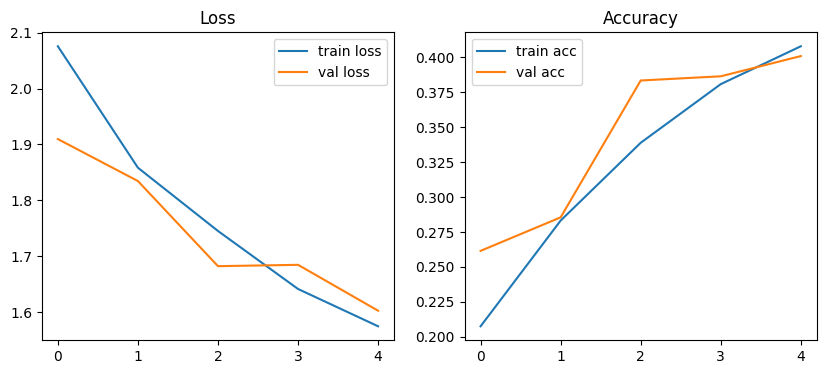

In [136]:
# Cargar CIFAR-10 (pequeño dataset de ejemplo)
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
# normalizar
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

num_classes = 10

model = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Entrenar pocas epochs para demo
history = model.fit(x_train[:10000], y_train[:10000],
                    epochs=5, batch_size=64,
                    validation_data=(x_test[:2000], y_test[:2000]))

# Visualizar métricas
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')
plt.show()


La CNN extrae características jerárquicas: capas iniciales detectan bordes y texturas, capas intermedias combinan patrones y capas profundas forman conceptos de alto nivel.

# Estrategias para mejorar una CNN
1. Aumentar la profundidad o complejidad
+ Más capas convolucionales y de pooling permiten capturar características más complejas.
+ Se puede añadir más filtros en cada capa para aprender más patrones.
2. Agregar regularización
+ Dropout entre capas para reducir overfitting.
+ BatchNormalization para estabilizar el entrenamiento y acelerar la convergencia.
3. Mejorar la función de activación
+ ReLU sigue siendo estándar, pero también están LeakyReLU o ELU.
4. Aumento de datos (Data Augmentation)
+ Rotaciones, escalado, cambios de brillo, volteo horizontal/vertical.
+ Permite que la red sea más robusta ante variaciones en imágenes reales.
5. Optimización del aprendizaje
+ Optimizer como Adam o RMSprop con tasas de aprendizaje adecuadas.
+ Learning rate scheduling para reducir el LR durante el entrenamiento.
6. Global Average Pooling o Flatten
+ Permite reducir dimensionalidad antes de las capas densas y evitar overfitting.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,218 (1.17 MB)

 Trainable params: 305,514 (1.17 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/10


/Users/carlosvasquezguerra/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.1621 - loss: 2.8452 - val_accuracy: 0.1010 - val_loss: 2.8802
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.2635 - loss: 2.1808 - val_accuracy: 0.1015 - val_loss: 3.2618
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.3137 - loss: 1.9335 - val_accuracy: 0.2260 - val_loss: 2.2835
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.3619 - loss: 1.7581 - val_accuracy: 0.4260 - val_loss: 1.6209
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.4137 - loss: 1.5790 - val_accuracy: 0.4560 - val_loss: 1.6164
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.4455 - loss: 1.4919 - val_accuracy: 0.2910 - val_loss: 3.0765
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.4807 - loss: 1.4136 - val_accuracy: 0.5265 - val_loss: 1.3348
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.4959 - loss: 1.3662 - val_accurac

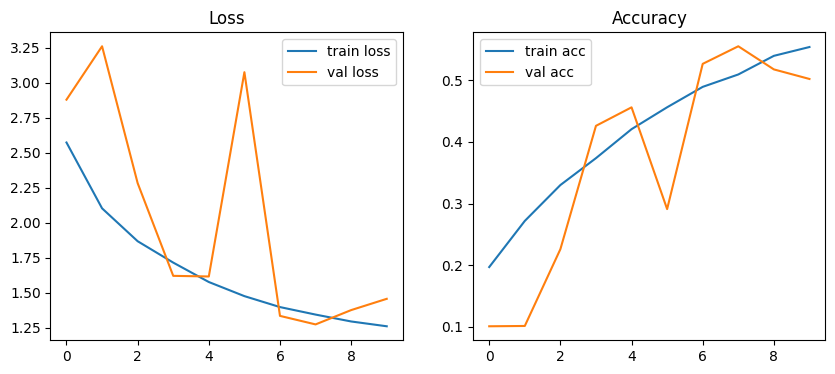

In [138]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# --- Cargar CIFAR-10 ---
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
num_classes = 10

# --- Data Augmentation ---
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

# --- Modelo CNN mejorado ---
model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
model.summary()

# --- Entrenamiento con subset para demo ---
history = model.fit(datagen.flow(x_train[:10000], y_train[:10000], batch_size=64),
                    epochs=10,
                    validation_data=(x_test[:2000], y_test[:2000]))

# --- Visualizar métricas ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.title('Accuracy')
plt.show()


Buenas prácticas y consideraciones

- Preprocesado: normalizar, igualar histograma (CLAHE), remover ruido.
- Aumentos: rotación, traslación, escalado, cambios de iluminación para robustecer modelos.
- Balance de parámetros: en detección de bordes y segmentación, ajustar sigma, umbrales y tamaño mínimo de región para evitar falsos positivos.
- Robustez: entrenar con ejemplos reflejando variabilidad (iluminación, oclusión, escala).